# LIBRA and the Lithium Oxide (Li2O) Packed Bed Blanket
## 1L BABY

In [1]:
import math
import openmc
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, ListedColormap
from openmc_model_LiOx import baby_model

**Li2O packed bed properties**
Oxygen mass fraction: 0.5354685949864236
Lithium mass fraction: 0.46451900615072256
Helium mass fraction: 1.2398862853919525e-05
Pellet bed density: 1.3386615978815597


### Geometry

In [2]:
model = baby_model()
geometry = model.geometry

isotopes ['Al27', 'Ar36', 'Ar38', 'Ar40', 'B10', 'B11', 'Be9', 'C12', 'C13', 'Ca40', 'Ca42', 'Ca43', 'Ca44', 'Ca46', 'Ca48', 'Co59', 'Cr50', 'Cr52', 'Cr53', 'Cr54', 'Cu63', 'Cu65', 'F19', 'Fe54', 'Fe56', 'Fe57', 'Fe58', 'H1', 'H2', 'He3', 'He4', 'K39', 'K40', 'K41', 'Li6', 'Li7', 'Mg24', 'Mg25', 'Mg26', 'Mn55', 'Mo100', 'Mo92', 'Mo94', 'Mo95', 'Mo96', 'Mo97', 'Mo98', 'N14', 'N15', 'Na23', 'Nb93', 'Ni58', 'Ni60', 'Ni61', 'Ni62', 'Ni64', 'O16', 'O17', 'O18', 'P31', 'Pb204', 'Pb206', 'Pb207', 'Pb208', 'S32', 'S33', 'S34', 'S36', 'Si28', 'Si29', 'Si30', 'Ti46', 'Ti47', 'Ti48', 'Ti49', 'Ti50', 'W182', 'W183', 'W184', 'W186', 'Zr90', 'Zr91', 'Zr92', 'Zr94', 'Zr96']
Searching libraries with the following priority {'ENDFB-8.0-NNDC': 1}
Isotopes found matching library requirements 556
Isotopes found matching particle requirements 1789
Isotopes found matching isotope requirements 337
Isotopes found matching all requirements 85
             library remote_file  \
1233  ENDFB-8.0-NNDC       H1.h5 

### Vault Geometry

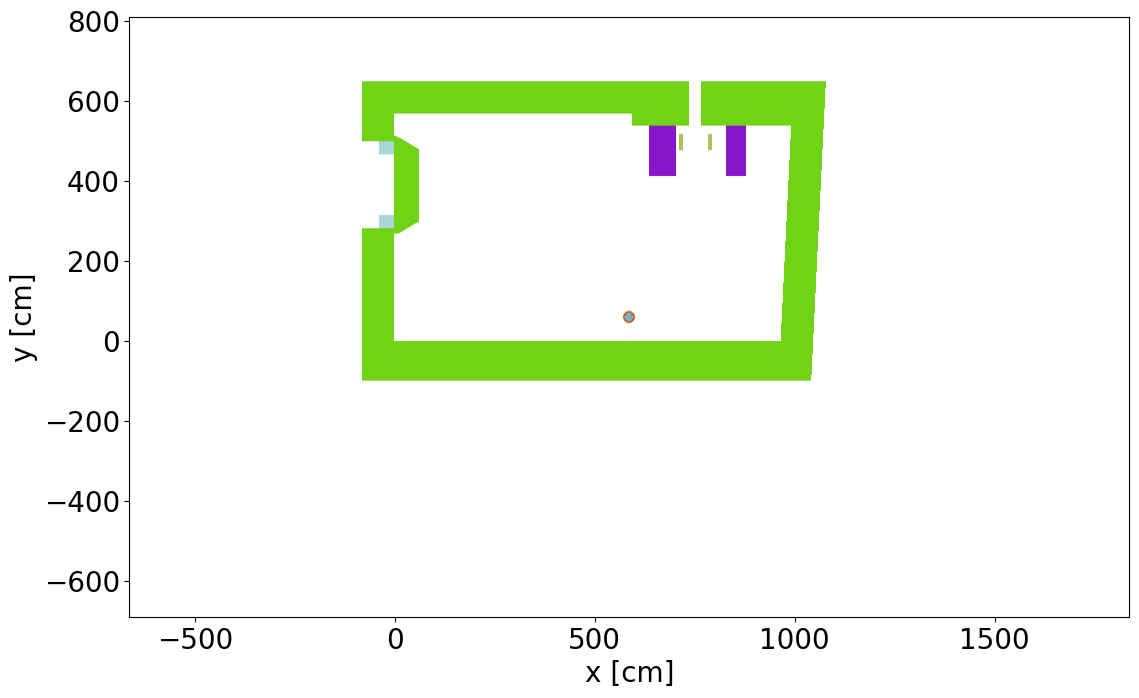

In [3]:
# Visualization

from libra_toolbox.neutronics.vault import Air
from openmc_model_LiOx import air

x_c = 587
y_c = 60
z_c = 100
ax = geometry.plot(
    width=(2500, 1500),
    origin=(x_c, y_c, z_c + 10),
    pixels=(1000, 1000),
    basis="xy",
    color_by="material",
    colors={Air: "white", air: "white"},
)
ax.tick_params(axis="both", labelsize=20)
ax.set_xlabel(ax.get_xlabel(), fontsize=20)
ax.set_ylabel(ax.get_ylabel(), fontsize=20)
plt.show()

### BABY 1L Geometry XZ View

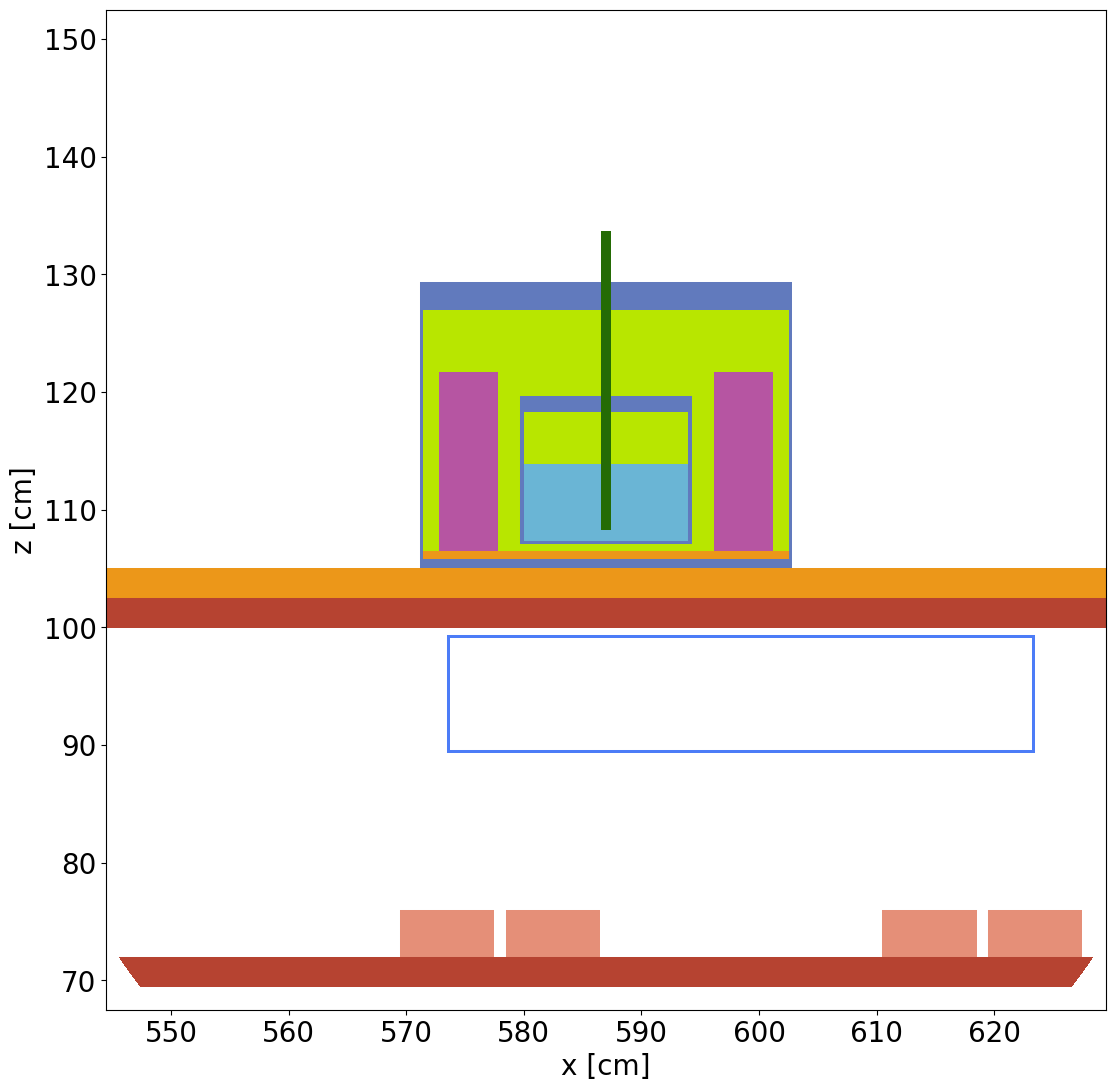

In [4]:
ax = geometry.plot(
    width=(85, 85),
    origin=(x_c, y_c, z_c + 10),
    pixels=(1000, 1000),
    basis="xz",
    color_by="material",
    colors={Air: "white", air: "white"},
)
ax.tick_params(axis="both", labelsize=20)
ax.set_xlabel(ax.get_xlabel(), fontsize=20)
ax.set_ylabel(ax.get_ylabel(), fontsize=20)
plt.show()

### BABY 1L Geometry YZ View

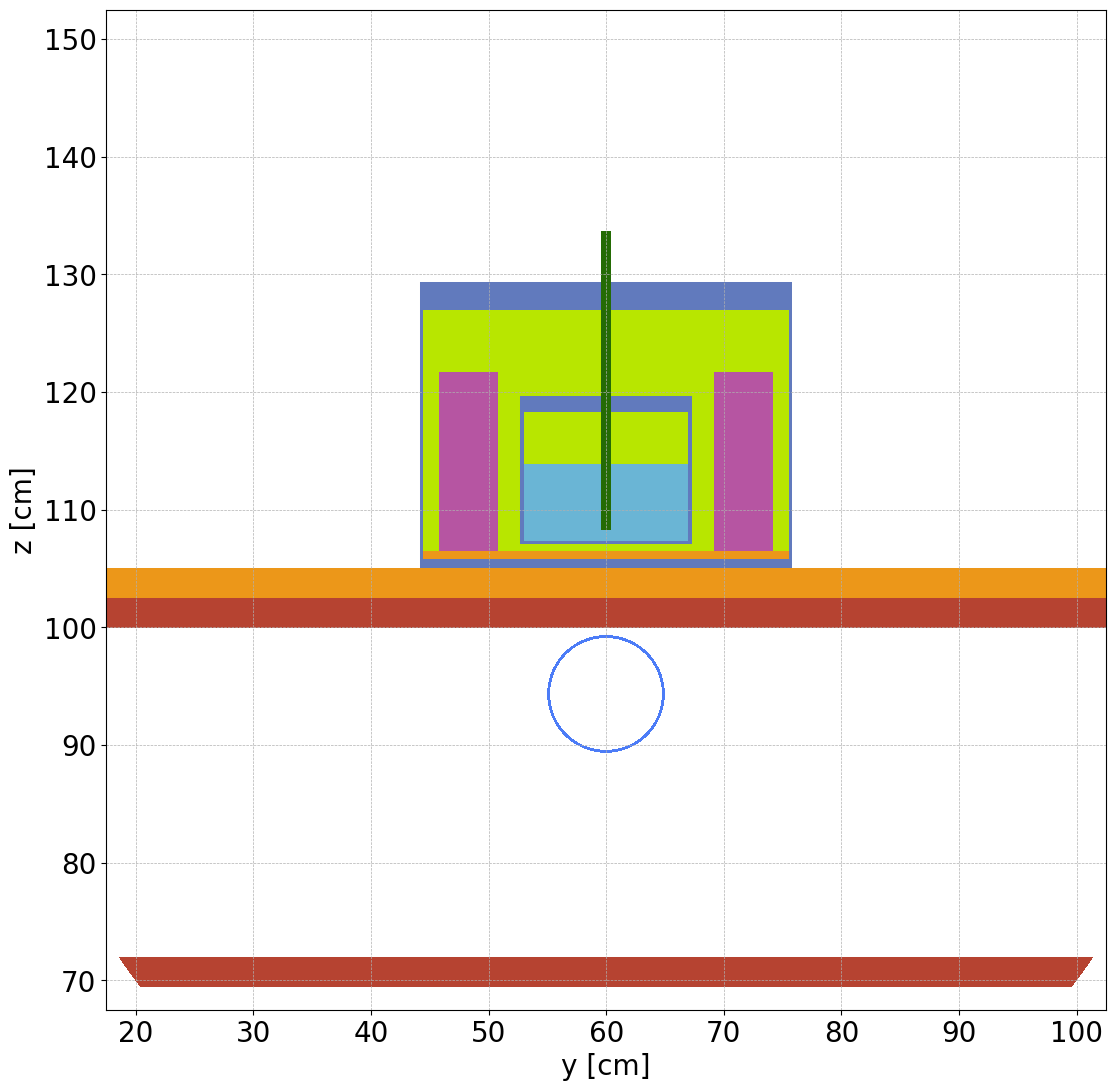

In [5]:
ax = geometry.plot(
    width=(85, 85),
    origin=(x_c, y_c, z_c + 10),
    pixels=(1000, 1000),
    basis="yz",
    color_by="material",
    colors={Air: "white", air: "white"},
)
ax.tick_params(axis="both", labelsize=20)
ax.set_xlabel(ax.get_xlabel(), fontsize=20)
ax.set_ylabel(ax.get_ylabel(), fontsize=20)
plt.grid(visible=True, which='both', linestyle='--', linewidth=0.5)  # Add gridlines
plt.show()

### BABY 1L Geometry XY View

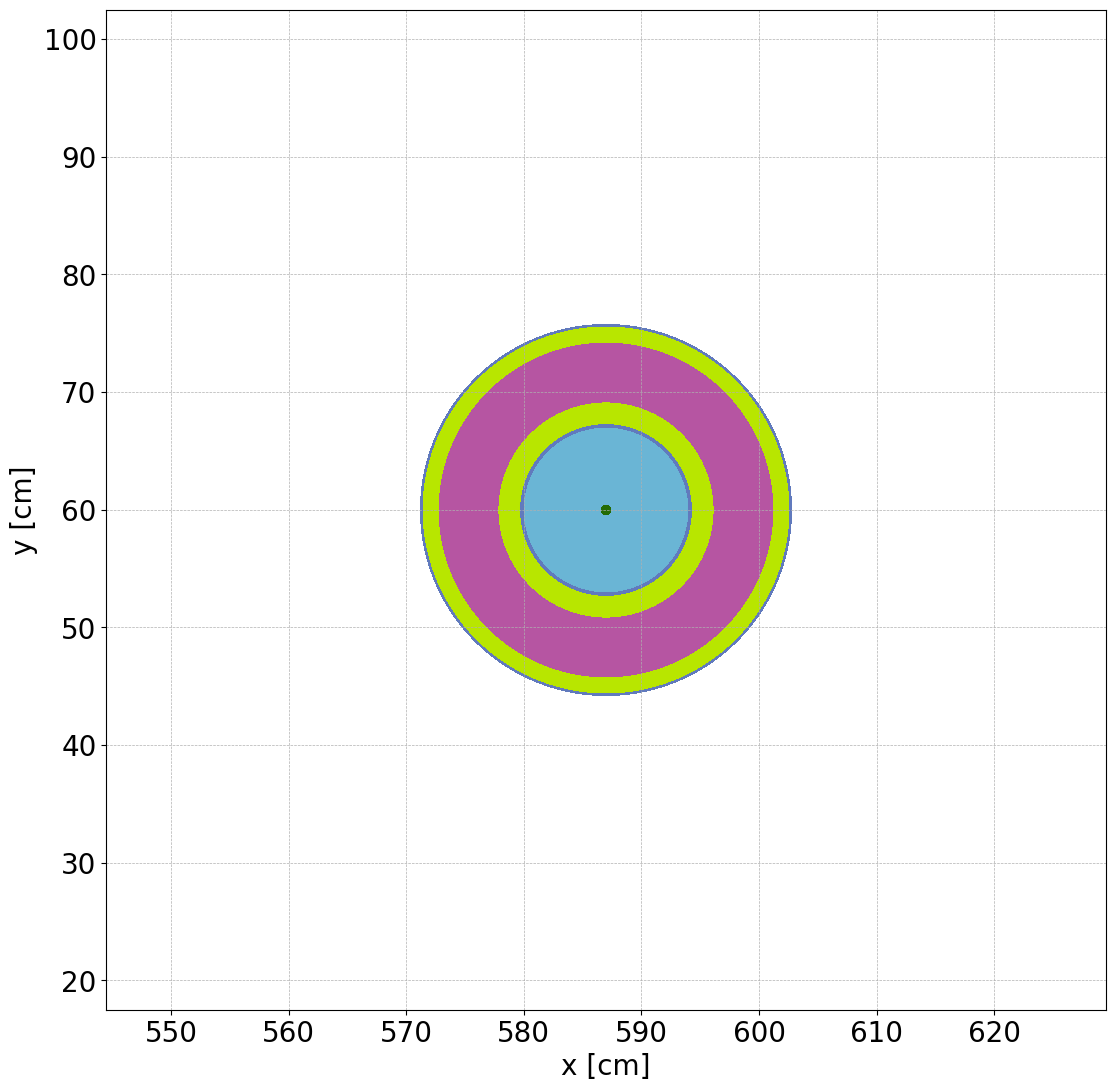

In [6]:
ax = geometry.plot(
    width=(85, 85),
    origin=(x_c, y_c, z_c + 10),
    pixels=(1000, 1000),
    basis="xy",
    color_by="material",
    colors={Air: "white", air: "white"},
)
ax.tick_params(axis="both", labelsize=20)
ax.set_xlabel(ax.get_xlabel(), fontsize=20)
ax.set_ylabel(ax.get_ylabel(), fontsize=20)
plt.grid(visible=True, which='both', linestyle='--', linewidth=0.5)  # Add gridlines
plt.show()

### Result

In [8]:
# Plot spatial distribution of TBR from cylindrical mesh data
sp = openmc.StatePoint("statepoint.100.h5")
tally = sp.get_tally(name="TBR")

# Print a info about the cell tally to the screen
print(tally)

# Get pandas dataframe for the cell tally data
df = tally.get_pandas_dataframe()

# # Get the mesh object from the tally filters
# mesh = None
# for f in tally.filters:
#     if isinstance(f, openmc.MeshFilter):
#         mesh = f.mesh
#         print(type(mesh))
#         break

# if mesh is None:
#     raise ValueError("No mesh filter found in the tally!")

# # Extract the number of bins for each dimension from the mesh
# n_r = len(mesh.r_grid) - 1  # Radial bins
# n_phi = len(mesh.phi_grid) - 1  # Angular binss
# n_z = len(mesh.z_grid) - 1  # Axial bins

# print("No. radial bins (x)", n_r)
# print("No. angular bins (y)", n_phi)
# print("No. axial bins (z)", n_z)

# # print(mesh.r_grid + mesh.mesh_origin[0]) 


# print("Dataframe:")
# print(df)

# mean = df['mean'].to_numpy()
# mesh.write_data_to_vtk('tally.vtk', datasets={'nxt': mean})

# # Convert to NumPy array & transpose
# mean_array = df['mean'].values.reshape((n_z, n_r)).T

# print("Reshaped data:")
# print(mean_array)

# print(mean_array.shape)

# plt.imshow(mean_array, interpolation='nearest', extent=[0, n_r/4, 0, n_z/4], origin='lower', aspect='auto')
# plt.title('Local TBR (LiOx bed X-section)')
# plt.xlabel('Radial pos (cm)')
# plt.ylabel('Axial pos (cm)')
# plt.colorbar()


Tally
	ID             =	1
	Name           =	TBR
	Filters        =	
	Nuclides       =	total
	Scores         =	['(n,Xt)']
	Estimator      =	tracklength
	Multiply dens. =	True


In [9]:

print(f"TBR: {df['mean'].iloc[0] :.6e}\n")
print(f"TBR std. dev.: {df['std. dev.'].iloc[0] :.6e}\n")

TBR: 4.830404e-03

TBR std. dev.: 4.344197e-05

